## 语义分割
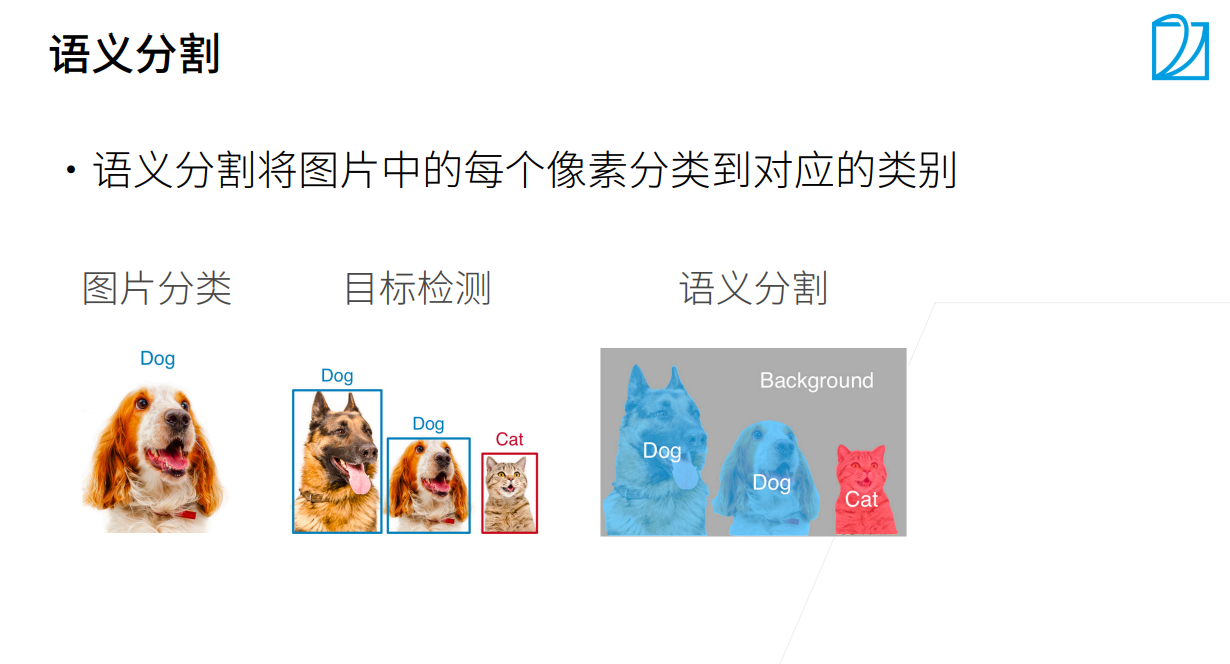
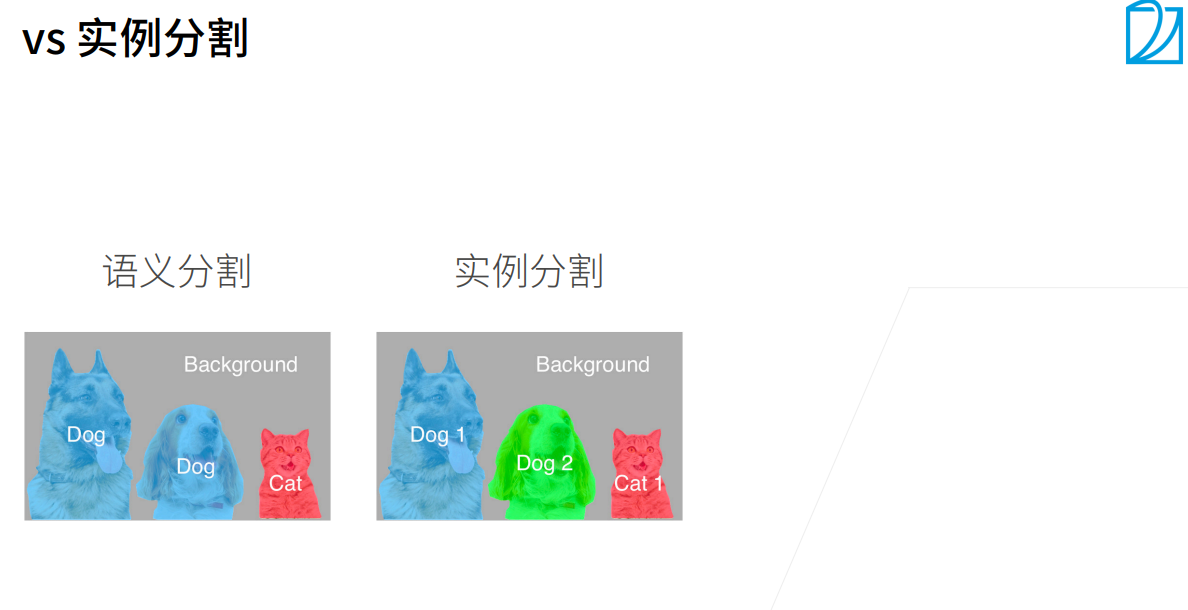
类似于抠图，语义分割只关心种类，而实例分割更加细化还关心是哪只狗。可以看做是目标检测的进阶版本

标注工具：label me

In [1]:
%matplotlib inline
import os
import torch
import torchvision
from d2l import torch as d2l

In [2]:
#@save
d2l.DATA_HUB['voc2012'] = (d2l.DATA_URL + 'VOCtrainval_11-May-2012.tar',
                           '4e443f8a2eca6b1dac8a6c57641b67dd40621a49')

voc_dir = d2l.download_extract('voc2012', 'VOCdevkit/VOC2012')

In [3]:
def read_voc_images(voc_dir, is_train = True):
    global images
    txt_fname = os.path.join(voc_dir, 'ImageSets','Segmentation','train.txt' if is_train else 'val.txt')
    mode = torchvision.io.image.ImageReadMode.RGB
    with open(txt_fname, 'r') as f:
        images = f.read().split()
    features, labels = [], []
    for i,fname in enumerate(images):
        features.append(torchvision.io.read_image(os.path.join(voc_dir, 'JPEGImages',f'{fname}.jpg')))
        labels.append(torchvision.io.read_image(os.path.join(voc_dir,'SegmentationClass',f'{fname}.png'),mode = mode))

    return features, labels

train_features,train_labels = read_voc_images(voc_dir,True)

In [31]:
images[:5]  # txt文件中的空格自动变成了下划线

['2007_000032', '2007_000039', '2007_000063', '2007_000068', '2007_000121']

In [22]:
txt_fname = os.path.join(voc_dir, 'ImageSets','Segmentation','train.txt')
with open(txt_fname) as f:
    a = f.read()

a[:100],len(a)

('2007_000032\n2007_000039\n2007_000063\n2007_000068\n2007_000121\n2007_000170\n2007_000241\n2007_000243\n2007',
 17568)

In [18]:
a.split()  # 根据换行符分割的

['2007_000032',
 '2007_000039',
 '2007_000063',
 '2007_000068',
 '2007_000121',
 '2007_000170',
 '2007_000241',
 '2007_000243',
 '2007_000250',
 '2007_000256',
 '2007_000333',
 '2007_000363',
 '2007_000364',
 '2007_000392',
 '2007_000480',
 '2007_000504',
 '2007_000515',
 '2007_000528',
 '2007_000549',
 '2007_000584',
 '2007_000645',
 '2007_000648',
 '2007_000713',
 '2007_000720',
 '2007_000733',
 '2007_000738',
 '2007_000768',
 '2007_000793',
 '2007_000822',
 '2007_000836',
 '2007_000876',
 '2007_000904',
 '2007_001027',
 '2007_001073',
 '2007_001149',
 '2007_001185',
 '2007_001225',
 '2007_001340',
 '2007_001397',
 '2007_001416',
 '2007_001420',
 '2007_001439',
 '2007_001487',
 '2007_001595',
 '2007_001602',
 '2007_001609',
 '2007_001698',
 '2007_001704',
 '2007_001709',
 '2007_001724',
 '2007_001764',
 '2007_001825',
 '2007_001834',
 '2007_001857',
 '2007_001872',
 '2007_001901',
 '2007_001917',
 '2007_001960',
 '2007_002024',
 '2007_002055',
 '2007_002088',
 '2007_002099',
 '2007_0

In [28]:
train_features[0]

tensor([[[131, 131, 131,  ..., 182, 182, 182],
         [132, 132, 133,  ..., 183, 183, 182],
         [133, 133, 134,  ..., 183, 183, 182],
         ...,
         [  6,   5,   7,  ...,  16,  16,  16],
         [  5,   9,  12,  ...,  16,  17,  17],
         [  5,   6,  10,  ...,  16,  12,  17]],

        [[193, 193, 193,  ..., 232, 232, 232],
         [194, 194, 195,  ..., 233, 233, 232],
         [195, 195, 196,  ..., 233, 233, 232],
         ...,
         [ 15,  14,  13,  ...,  34,  34,  34],
         [ 14,  18,  17,  ...,  34,  35,  35],
         [ 15,  16,  18,  ...,  33,  29,  34]],

        [[208, 208, 208,  ..., 241, 241, 241],
         [209, 209, 210,  ..., 242, 242, 241],
         [210, 210, 211,  ..., 242, 242, 241],
         ...,
         [ 14,  13,  13,  ...,  38,  38,  38],
         [ 13,  17,  20,  ...,  38,  39,  39],
         [ 14,  15,  20,  ...,  40,  36,  41]]], dtype=torch.uint8)

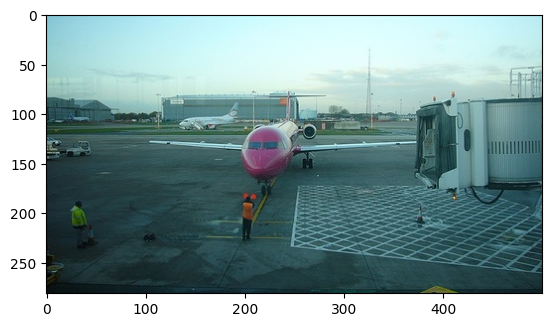

In [30]:
d2l.plt.imshow(train_features[0].permute(1,2,0)) # imshow中通道数在最后面的

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

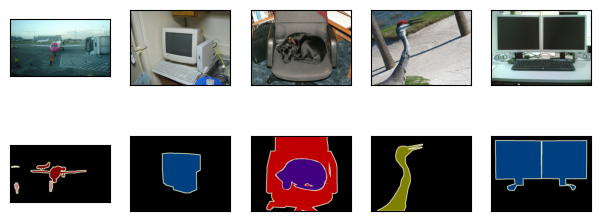

In [32]:
imgs = train_features[:5] + train_labels[:5]
imgs = [img.permute(1,2,0) for img in imgs]
d2l.show_images(imgs, 2, 5)

In [4]:
#@save
VOC_COLORMAP = [[0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0],
                [0, 0, 128], [128, 0, 128], [0, 128, 128], [128, 128, 128],
                [64, 0, 0], [192, 0, 0], [64, 128, 0], [192, 128, 0],
                [64, 0, 128], [192, 0, 128], [64, 128, 128], [192, 128, 128],
                [0, 64, 0], [128, 64, 0], [0, 192, 0], [128, 192, 0],
                [0, 64, 128]]

#@save
VOC_CLASSES = ['background', 'aeroplane', 'bicycle', 'bird', 'boat',
               'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
               'diningtable', 'dog', 'horse', 'motorbike', 'person',
               'potted plant', 'sheep', 'sofa', 'train', 'tv/monitor']

In [5]:
#@save
def voc_colormap2label():
    """构建从RGB到VOC类别索引的映射"""
    colormap2label = torch.zeros(256 ** 3, dtype=torch.long)
    for i, colormap in enumerate(VOC_COLORMAP):
        colormap2label[
            (colormap[0] * 256 + colormap[1]) * 256 + colormap[2]] = i
    return colormap2label

#@save
def voc_label_indices(colormap, colormap2label):
    """将VOC标签中的RGB值映射到它们的类别索引"""
    colormap = colormap.permute(1, 2, 0).numpy().astype('int32')
    idx = ((colormap[:, :, 0] * 256 + colormap[:, :, 1]) * 256
           + colormap[:, :, 2])
    return colormap2label[idx]

In [49]:
train_labels[0].permute(1,2,0)[:,:,0]

tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]], dtype=torch.uint8)

In [102]:
colormap = train_labels[0]
((colormap[0, :, :] * 256 + colormap[1, :, :]) * 256
           + colormap[2, :, :]).shape

torch.Size([281, 500])

In [100]:
    colormap = colormap.permute(1, 2, 0).numpy().astype('int32')
    idx = ((colormap[:, :, 0] * 256 + colormap[:, :, 1]) * 256
           + colormap[:, :, 2]).shape


AttributeError: 'numpy.ndarray' object has no attribute 'permute'

In [101]:
idx

(281, 500)

In [68]:
colormap = train_labels[0].numpy()
((colormap[0, :, :] * 256 + colormap[1, :, :]) * 256
           + colormap[2, :, :])

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint16)

In [78]:
w=torch.arange(18).view(6,3)
w

tensor([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11],
        [12, 13, 14],
        [15, 16, 17]])

In [79]:
w[[1,2,3],[0,1,2]]  # 对应位置作为坐标

tensor([ 3,  7, 11])

In [83]:
w[torch.tensor([[1,2,3],[0,1,2]])] 
#二维Tensor作为索引时，每个索引中的元素都作为w的第一维度的下标（即行号）用于选择w中第一维的元素。
# 下面例子中，索引形状为[2,3]，将索引中的每个元素用被索引的Tensor中对应行号的行替换之后，由于每一行有三列，故得到了[2,3,3]的结果

tensor([[[ 3,  4,  5],
         [ 6,  7,  8],
         [ 9, 10, 11]],

        [[ 0,  1,  2],
         [ 3,  4,  5],
         [ 6,  7,  8]]])

In [93]:
w[torch.tensor([[[1,2,3],[0,1,2]]])]

tensor([[[[ 3,  4,  5],
          [ 6,  7,  8],
          [ 9, 10, 11]],

         [[ 0,  1,  2],
          [ 3,  4,  5],
          [ 6,  7,  8]]]])

In [108]:
w[np.array([[1,2,3],[0,1,2]],dtype=int)]  # 二维索引会一个个取出来对应的数值（可能会取出矩阵、向量等 可能会生维度 ）

tensor([[[ 3,  4,  5],
         [ 6,  7,  8],
         [ 9, 10, 11]],

        [[ 0,  1,  2],
         [ 3,  4,  5],
         [ 6,  7,  8]]])

In [104]:
w[list([[1,2,3],[0,1,2]])]  # list无论如何都是各自匹配并索引

tensor([ 3,  7, 11])

In [90]:
w[[[1,2,3],[0,1,2]]]

tensor([ 3,  7, 11])

In [89]:
torch.tensor([[0,1],[2,3]])

tensor([[0, 1],
        [2, 3]])

In [87]:
voc_colormap2label()[torch.tensor([[0,1],[2,3]])]

tensor([[0, 0],
        [0, 0]])

In [75]:
voc_colormap2label()[np.array([[0,1],[2,3]])]

tensor([[0, 0],
        [0, 0]])

In [97]:
voc_colormap2label()[((colormap[0, :, :] * 256 + colormap[1, :, :]) * 256
           + colormap[2, :, :])]

IndexError: too many indices for tensor of dimension 1

In [91]:
voc_colormap2label()[((colormap[0, :, :] * 256 + colormap[1, :, :]) * 256
           + colormap[2, :, :])]

TypeError: can't convert np.ndarray of type numpy.uint16. The only supported types are: float64, float32, float16, complex64, complex128, int64, int32, int16, int8, uint8, and bool.

In [94]:
def myvoc_label_indices(colormap, colormap2label):
    """将VOC标签中的RGB值映射到它们的类别索引"""
    # colormap = colormap.numpy().astype('int32')
    idx = ((colormap[0, :, :] * 256 + colormap[1, :, :]) * 256
           + colormap[2, :, :])
    return colormap2label[idx]  # 没有必要一定要permute

In [51]:
y = voc_label_indices(train_labels[0], voc_colormap2label())
y[105:115, 130:140], VOC_CLASSES[1]

(tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
         [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
         [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 1, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 0, 0, 0, 1, 1]]),
 'aeroplane')

In [95]:
y = myvoc_label_indices(train_labels[0], voc_colormap2label())
y[105:115, 130:140], VOC_CLASSES[1]

IndexError: too many indices for tensor of dimension 1

In [59]:
import numpy as np
voc_colormap2label()[np.array([1,2,3])]

tensor([0, 0, 0])

In [60]:
voc_colormap2label()[[1,2,3]]

tensor([0, 0, 0])

In [62]:
voc_colormap2label()[[[1,2,3]]]

tensor([0, 0, 0])

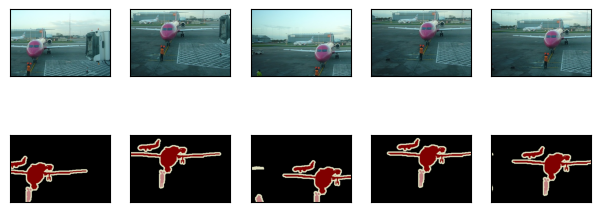

In [6]:
#@save  裁剪输入图像和标签的相同区域
n=5
def voc_rand_crop(feature, label, height, width):
    """随机裁剪特征和标签图像"""
    rect = torchvision.transforms.RandomCrop.get_params(
        feature, (height, width))
    feature = torchvision.transforms.functional.crop(feature, *rect)
    label = torchvision.transforms.functional.crop(label, *rect)
    return feature, label

imgs = []
for _ in range(n):
    imgs += voc_rand_crop(train_features[0], train_labels[0], 200, 300)

imgs = [img.permute(1, 2, 0) for img in imgs]
d2l.show_images(imgs[::2] + imgs[1::2], 2, n);

In [7]:
#@save
class VOCSegDataset(torch.utils.data.Dataset):
    """一个用于加载VOC数据集的自定义数据集"""
    # 这里没有resize 因为分割的标签是一张图片,进行拉伸会有没有意义的插值
    def __init__(self, is_train, crop_size, voc_dir): 
        self.transform = torchvision.transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # 这里是小数，所以应该把图片弄成0-1的float形式
        self.crop_size = crop_size
        features, labels = read_voc_images(voc_dir, is_train=is_train)
        self.features = [self.normalize_image(feature)
                         for feature in self.filter(features)]
        self.labels = self.filter(labels)  # 调用自己定义的函数也是self.func(X)## 参数中不用写self
        self.colormap2label = voc_colormap2label()
        print('read ' + str(len(self.features)) + ' examples')

    def normalize_image(self, img):
        return self.transform(img.float() / 255)

    def filter(self, imgs):
        return [img for img in imgs if (
            img.shape[1] >= self.crop_size[0] and
            img.shape[2] >= self.crop_size[1])]   # 图片比裁剪还小就不要了

    def __getitem__(self, idx):
        feature, label = voc_rand_crop(self.features[idx], self.labels[idx],
                                       *self.crop_size)
        return (feature, voc_label_indices(label, self.colormap2label)) 
        # 注意这里label不能归一化 必须是证书 否则voc_label_indices函数无效了

    def __len__(self):
        return len(self.features)

In [8]:
crop_size = (320, 480)
voc_train = VOCSegDataset(True, crop_size, voc_dir)
voc_test = VOCSegDataset(False, crop_size, voc_dir)

read 1114 examples
read 1078 examples


In [113]:
voc_train.features

[tensor([[[ 0.6906,  0.7933,  0.8104,  ..., -1.1589, -1.1247, -1.1075],
          [ 0.6563,  0.6906,  0.7591,  ..., -1.0904, -1.0733, -1.0562],
          [ 0.7419,  0.7591,  0.8276,  ..., -1.0904, -1.0904, -1.0904],
          ...,
          [-0.4568, -0.4568, -0.4226,  ..., -1.0048, -0.9705, -0.9192],
          [-0.5596, -0.5424, -0.4911,  ..., -0.9534, -0.9705, -0.9705],
          [-0.5424, -0.5253, -0.5253,  ..., -0.8678, -0.9020, -0.9534]],
 
         [[ 0.8529,  0.9580,  1.0105,  ..., -1.1078, -1.0728, -1.0553],
          [ 0.8179,  0.8529,  0.9580,  ..., -1.0378, -1.0203, -1.0028],
          [ 0.9055,  0.9230,  0.9930,  ..., -1.0378, -1.0378, -1.0378],
          ...,
          [-0.3200, -0.3200, -0.2500,  ..., -0.8102, -0.7752, -0.7402],
          [-0.4251, -0.4076, -0.3200,  ..., -0.7577, -0.7752, -0.7927],
          [-0.4076, -0.3901, -0.3550,  ..., -0.6702, -0.7052, -0.7577]],
 
         [[ 0.7576,  0.8622,  0.8622,  ..., -1.2119, -1.1770, -1.1596],
          [ 0.7228,  0.7576,

In [120]:
voc_train[0]

(tensor([[[ 0.5707,  0.5878,  0.5878,  ..., -1.0904, -1.1075, -1.0904],
          [ 0.6049,  0.5536,  0.5878,  ..., -1.1247, -1.0904, -1.0904],
          [ 0.6392,  0.6049,  0.6049,  ..., -1.1589, -1.0562, -1.0733],
          ...,
          [-0.1999, -0.1657, -0.1486,  ...,  0.1426,  0.1597,  0.0741],
          [-0.2342, -0.1999, -0.1828,  ...,  0.1254,  0.1597,  0.1083],
          [-0.2171, -0.2342, -0.1143,  ...,  0.0056,  0.1426,  0.1939]],
 
         [[ 0.7304,  0.7479,  0.7479,  ..., -1.0378, -1.0553, -1.0378],
          [ 0.7654,  0.7129,  0.7829,  ..., -1.0728, -1.0378, -1.0378],
          [ 0.8004,  0.7654,  0.8004,  ..., -1.1078, -1.0028, -1.0203],
          ...,
          [-0.0574, -0.0224, -0.0049,  ...,  0.4328,  0.5203,  0.4853],
          [-0.0924, -0.0574, -0.0399,  ...,  0.4503,  0.5553,  0.5378],
          [-0.0924, -0.1099,  0.0126,  ...,  0.4503,  0.6429,  0.6954]],
 
         [[ 0.6705,  0.6879,  0.6879,  ..., -1.0724, -1.1247, -1.1421],
          [ 0.7054,  0.6531,

In [124]:
voc_train[0][1].sum(),voc_train[0][1].shape

(tensor(600620), torch.Size([320, 480]))

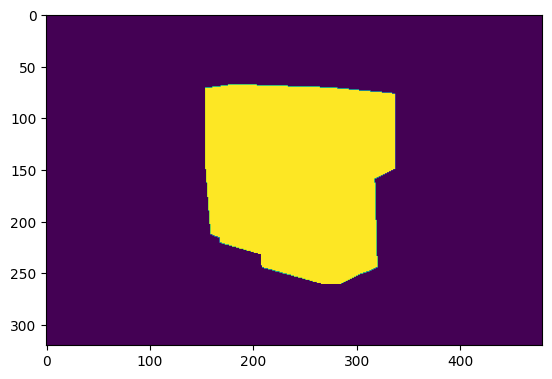

In [123]:
d2l.plt.imshow(voc_train[0][1])

In [133]:
(train_labels[0][0] ==128).sum()

tensor(4734)

In [ ]:
batch_size = 64
train_iter = torch.utils.data.DataLoader(voc_train, batch_size, shuffle=True,
                                    drop_last=True,
                                    num_workers=d2l.get_dataloader_workers())
for X, Y in train_iter:
    print(X.shape)
    print(Y.shape)
    break

In [ ]:
#@save
def load_data_voc(batch_size, crop_size):
    """加载VOC语义分割数据集"""
    voc_dir = d2l.download_extract('voc2012', os.path.join(
        'VOCdevkit', 'VOC2012'))
    num_workers = d2l.get_dataloader_workers()
    train_iter = torch.utils.data.DataLoader(
        VOCSegDataset(True, crop_size, voc_dir), batch_size,
        shuffle=True, drop_last=True, num_workers=num_workers)
    test_iter = torch.utils.data.DataLoader(
        VOCSegDataset(False, crop_size, voc_dir), batch_size,
        drop_last=True, num_workers=num_workers)
    return train_iter, test_iter

## 转置卷积

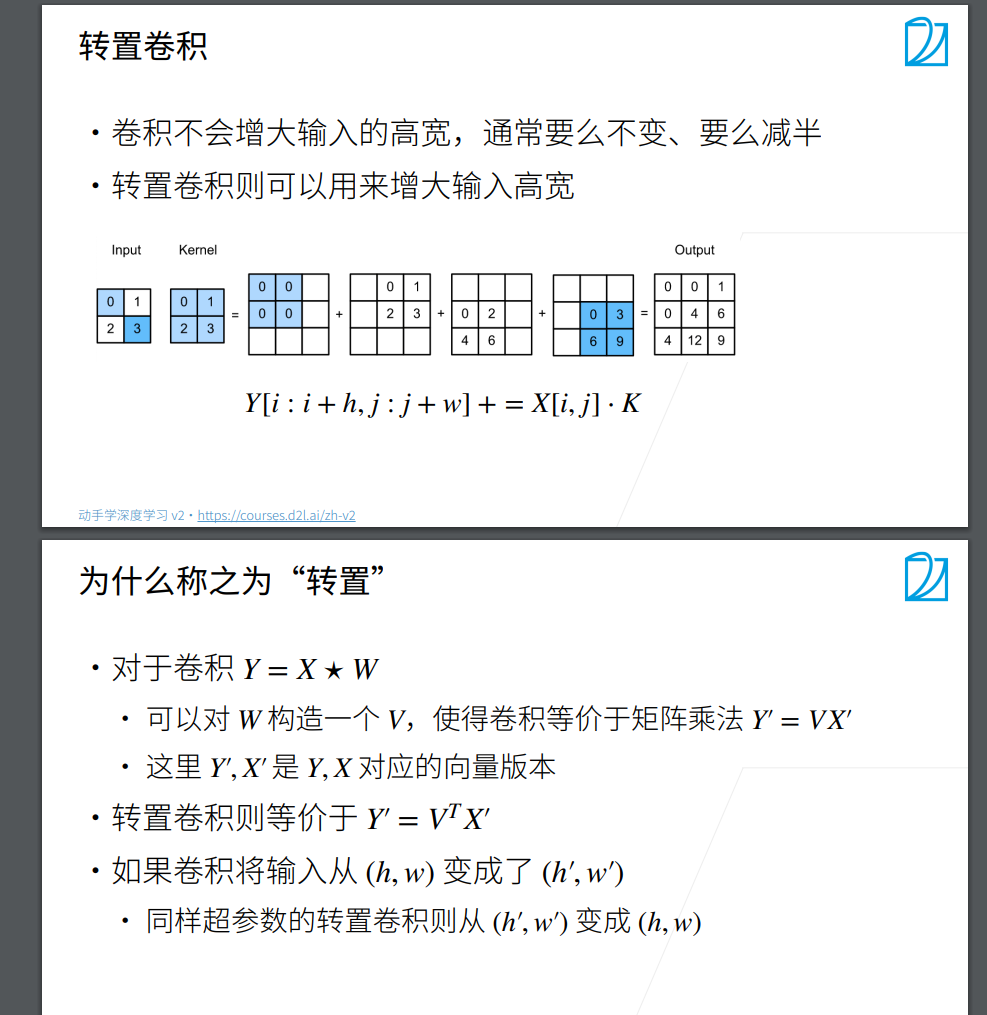
转置卷积是能够让图片变大的，在分割的时候，某个像素是猫，变大它为了让它真的变成猫，有点上采样的意思。
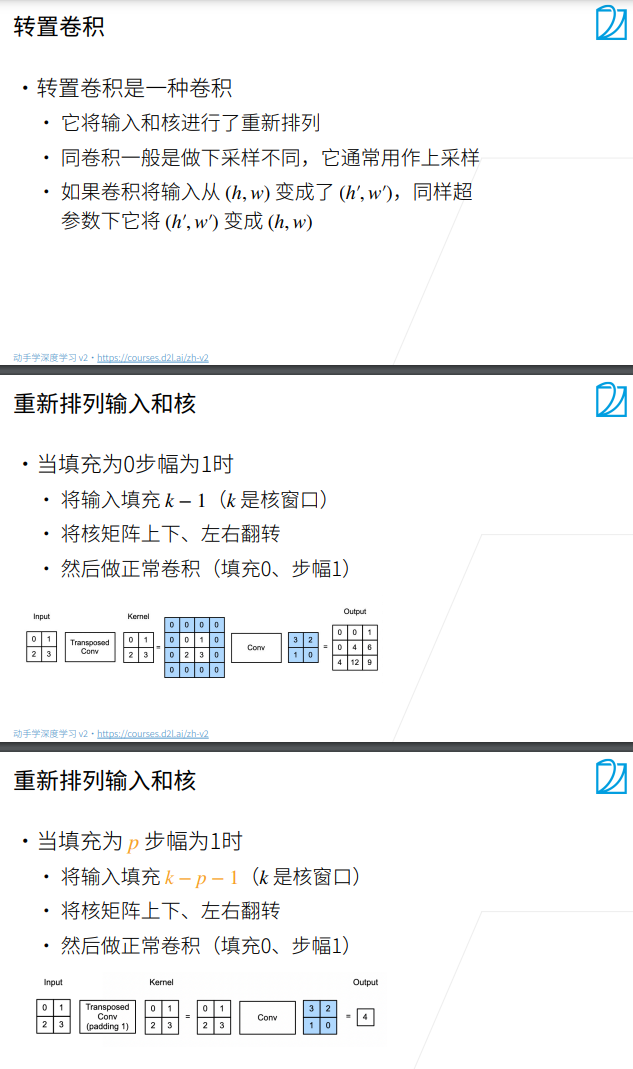
注意 这里的p是单边的p
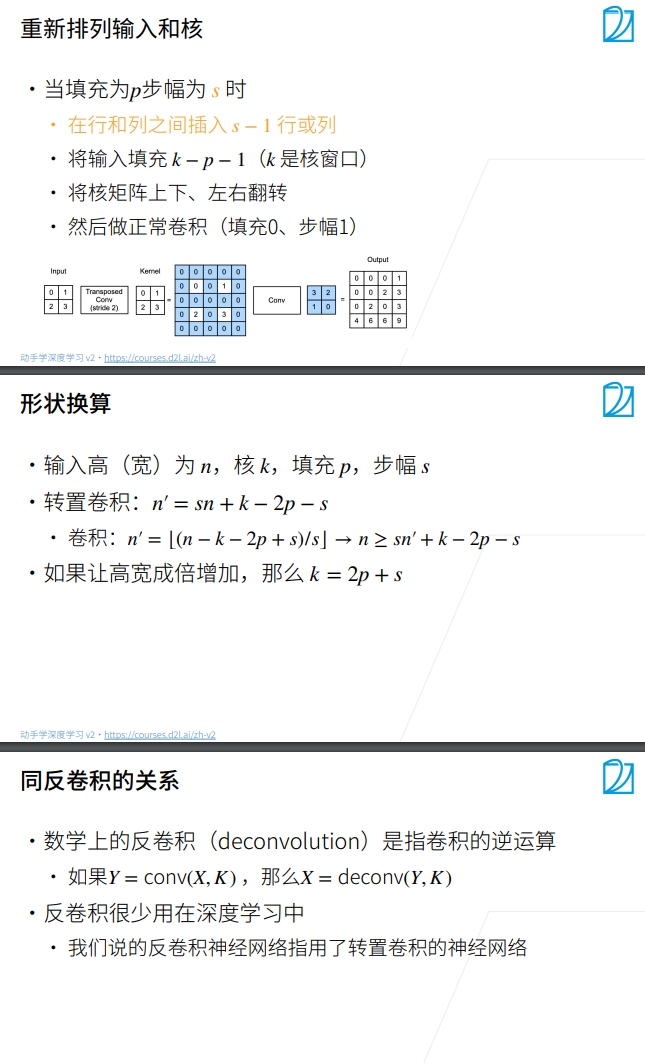

224变7 是32倍，所以要扩大32倍，所以就是s=32，因为k的窗口是64，所以p是16

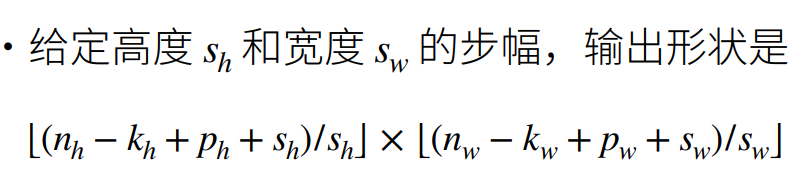
这是卷积层的公式 如果是转置卷积，应该是加减互换，乘除互换

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

In [2]:
def trans_conv(X, K):
    h,w = K.shape
    Y = torch.zeros(X.shape[0]+h-1, X.shapeh[1]+w-1)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Y[i:i+h, j:j+w] += X[i,j] * K
    return Y

In [3]:
X = torch.tensor([[0.0, 1.0], [2.0, 3.0]])
K = torch.tensor([[0.0, 1.0], [2.0, 3.0]])
trans_conv(X, K)

tensor([[ 0.,  0.,  1.],
        [ 0.,  4.,  6.],
        [ 4., 12.,  9.]])

In [4]:
X, K = X.reshape(1, 1, 2, 2), K.reshape(1, 1, 2, 2)
tconv = nn.ConvTranspose2d(1, 1, kernel_size=2, bias=False)
tconv.weight.data = K
tconv(X)


tensor([[[[ 0.,  0.,  1.],
          [ 0.,  4.,  6.],
          [ 4., 12.,  9.]]]], grad_fn=<ConvolutionBackward0>)

In [5]:
# 是去掉输出的padding大小行或列
tconv = nn.ConvTranspose2d(1, 1, kernel_size=2, padding=1, bias=False)
tconv.weight.data = K
tconv(X)

tensor([[[[4.]]]], grad_fn=<ConvolutionBackward0>)

In [6]:
tconv = nn.ConvTranspose2d(1, 1, kernel_size=2, stride=2, bias=False)
tconv.weight.data = K
tconv(X)

tensor([[[[0., 0., 0., 1.],
          [0., 0., 2., 3.],
          [0., 2., 0., 3.],
          [4., 6., 6., 9.]]]], grad_fn=<ConvolutionBackward0>)

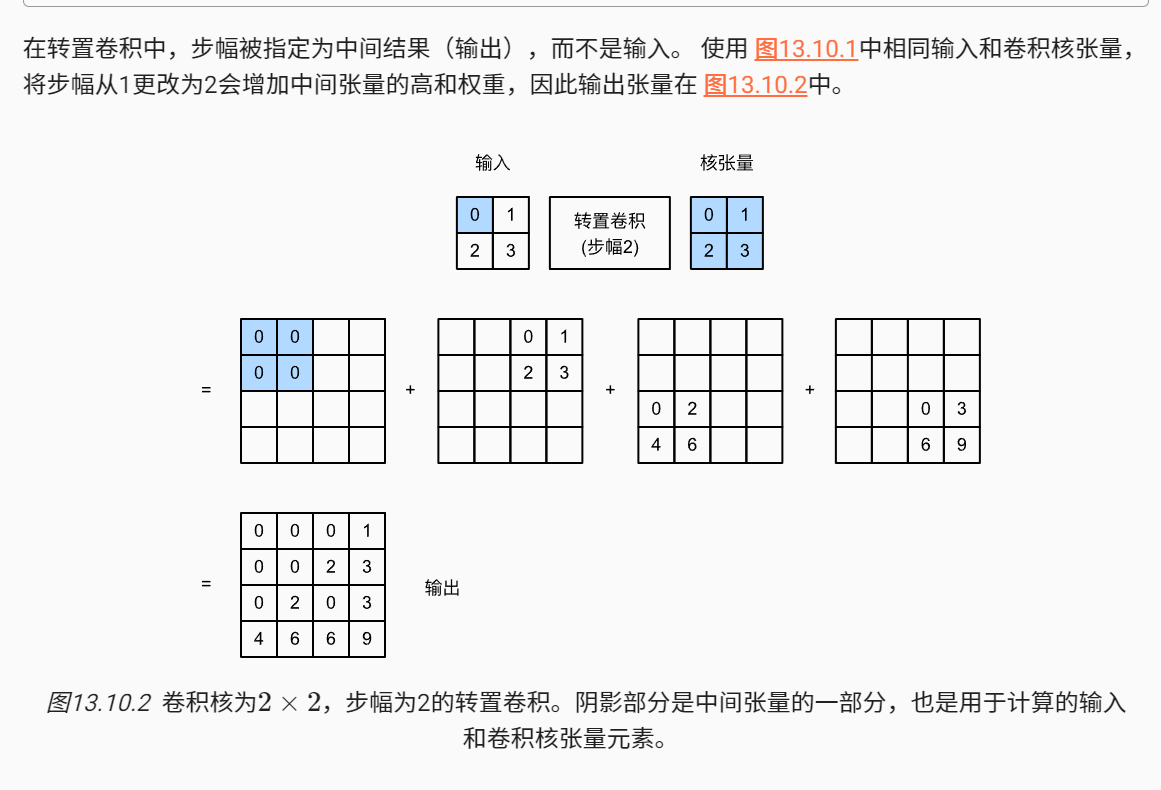

In [7]:
X = torch.rand(size=(1, 10, 16, 16))
conv = nn.Conv2d(10, 20, kernel_size=5, padding=2, stride=3)
tconv = nn.ConvTranspose2d(20, 10, kernel_size=5, padding=2, stride=3)
tconv(conv(X)).shape == X.shape

True

In [8]:
X = torch.arange(9.0).reshape(3, 3)
K = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
Y = d2l.corr2d(X, K)
Y

tensor([[27., 37.],
        [57., 67.]])

In [11]:
trans_conv(Y,K)  # 只是shape一样 不会值变回去的

tensor([[ 27.,  91.,  74.],
        [138., 400., 282.],
        [171., 429., 268.]])

In [12]:
def kernel2matrix(K):
    global k
    k, W = torch.zeros(5), torch.zeros((4, 9))  # 输入3*3 输出2*2 所以是4*9   k的长度是9-4
    k[:2], k[3:5] = K[0, :], K[1, :]
    W[0, :5], W[1, 1:6], W[2, 3:8], W[3, 4:] = k, k, k, k
    return W

W = kernel2matrix(K)
W

tensor([[1., 2., 0., 3., 4., 0., 0., 0., 0.],
        [0., 1., 2., 0., 3., 4., 0., 0., 0.],
        [0., 0., 0., 1., 2., 0., 3., 4., 0.],
        [0., 0., 0., 0., 1., 2., 0., 3., 4.]])

In [13]:
k

tensor([1., 2., 0., 3., 4.])

In [16]:
K

tensor([[1., 2.],
        [3., 4.]])

In [17]:
X.reshape(-1)

tensor([0., 1., 2., 3., 4., 5., 6., 7., 8.])

In [18]:
torch.matmul(X.reshape(-1),X.reshape(-1))

tensor(204.)

In [19]:
torch.mm(X.reshape(-1),X.reshape(-1))

RuntimeError: self must be a matrix

In [20]:
torch.mv(X.reshape(-1),X.reshape(-1))

RuntimeError: vector + matrix @ vector expected, got 1, 1, 1

In [21]:
X.reshape(-1)@X.reshape(-1)

tensor(204.)

In [24]:
Y == (W@X.reshape(-1)).reshape(2,2)

tensor([[True, True],
        [True, True]])

In [25]:
Y == torch.matmul(W, X.reshape(-1)).reshape(2, 2)

tensor([[True, True],
        [True, True]])

In [28]:
Z = trans_conv(Y,K)
Z

tensor([[ 27.,  91.,  74.],
        [138., 400., 282.],
        [171., 429., 268.]])

In [29]:
Z == torch.matmul(W.T, Y.reshape(-1)).reshape(3,3)

tensor([[True, True, True],
        [True, True, True],
        [True, True, True]])

## 全连接卷积神经网络
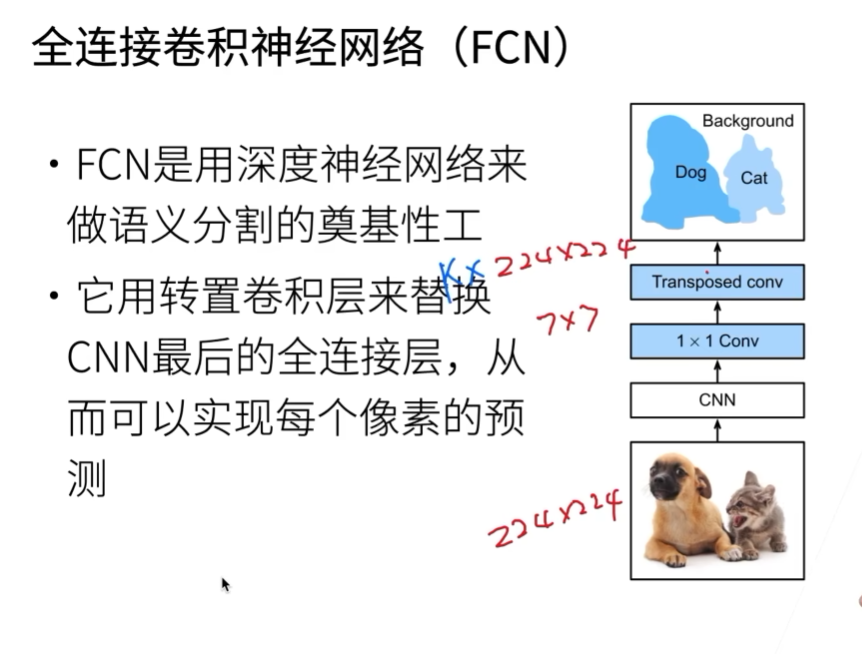
K的大小一共有多少类。CNN一般是一个pretrain好的模型

In [2]:
%matplotlib inline
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

In [3]:
pretrained_net = torchvision.models.resnet18(pretrained=True)
list(pretrained_net.children())[-3:]

D:\Pycharm\venv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
D:\Pycharm\venv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


[Sequential(
   (0): BasicBlock(
     (conv1): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
     (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (relu): ReLU(inplace=True)
     (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (downsample): Sequential(
       (0): Conv2d(256, 512, kernel_size=(1, 1), stride=(2, 2), bias=False)
       (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     )
   )
   (1): BasicBlock(
     (conv1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (relu): ReLU(inplace=True)
     (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn2): Batc

In [4]:
list(pretrained_net)[-3:]

TypeError: 'ResNet' object is not iterable

In [5]:
[*pretrained_net.children()]

[Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False),
 BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True),
 ReLU(inplace=True),
 MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False),
 Sequential(
   (0): BasicBlock(
     (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (relu): ReLU(inplace=True)
     (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   )
   (1): BasicBlock(
     (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (relu): ReLU(inplace=True)
     (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), pad

In [6]:
net = nn.Sequential(*list(pretrained_net.children())[:-2])
X = torch.rand((1,3,320,480))
net(X).shape  # 会缩小32倍

torch.Size([1, 512, 10, 15])

In [7]:
num_classes = 21
net.add_module('final_conv', nn.Conv2d(512, num_classes, kernel_size=1))
# 这里是num_classes通道数是因为后面卷积的计算量还是比较大的,这样能够减少后续的计算量 这是约定俗成的
net.add_module('transpose_conv', nn.ConvTranspose2d(num_classes, num_classes,
                                    kernel_size=64, padding=16, stride=32)) # 变回原来的32倍大小

In [8]:
def bilinear_kernel(in_channels, out_channels, kernel_size):
    factor = (kernel_size + 1) // 2
    if kernel_size % 2 == 1:
        center = factor - 1
    else:
        center = factor - 0.5
    og = (torch.arange(kernel_size).reshape(-1, 1),
          torch.arange(kernel_size).reshape(1, -1))
    filt = (1 - torch.abs(og[0] - center) / factor) * \
           (1 - torch.abs(og[1] - center) / factor)
    weight = torch.zeros((in_channels, out_channels,
                          kernel_size, kernel_size))
    weight[range(in_channels), range(out_channels), :, :] = filt  
    # 会给出一个权重矩阵 距离中心越近权重越高
    return weight

In [9]:
kk = bilinear_kernel(2, 2, 3)
print(kk)

tensor([[[[0.2500, 0.5000, 0.2500],
          [0.5000, 1.0000, 0.5000],
          [0.2500, 0.5000, 0.2500]],

         [[0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000]]],


        [[[0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000]],

         [[0.2500, 0.5000, 0.2500],
          [0.5000, 1.0000, 0.5000],
          [0.2500, 0.5000, 0.2500]]]])


In [10]:
kk[range(2), range(2), :, :]  # 分别给0,0 和 1,1的两个矩阵进行赋值

tensor([[[0.2500, 0.5000, 0.2500],
         [0.5000, 1.0000, 0.5000],
         [0.2500, 0.5000, 0.2500]],

        [[0.2500, 0.5000, 0.2500],
         [0.5000, 1.0000, 0.5000],
         [0.2500, 0.5000, 0.2500]]])

In [11]:
conv_trans = nn.ConvTranspose2d(3, 3, kernel_size=4, padding=1, stride=2,
                                bias=False)
conv_trans.weight.data.copy_(bilinear_kernel(3, 3, 4))


tensor([[[[0.0625, 0.1875, 0.1875, 0.0625],
          [0.1875, 0.5625, 0.5625, 0.1875],
          [0.1875, 0.5625, 0.5625, 0.1875],
          [0.0625, 0.1875, 0.1875, 0.0625]],

         [[0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000]],

         [[0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000]]],


        [[[0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000]],

         [[0.0625, 0.1875, 0.1875, 0.0625],
          [0.1875, 0.5625, 0.5625, 0.1875],
          [0.1875, 0.5625, 0.5625, 0.1875],
          [0.0625, 0.1875, 0.1875, 0.0625]],

         [[0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0

In [12]:
img = torchvision.transforms.ToTensor()(d2l.Image.open('../data/img/catdog.jpg'))
X = img.unsqueeze(0)
Y = conv_trans(X)
out_img = Y[0].permute(1, 2, 0).detach()

input image shape: torch.Size([561, 728, 3])


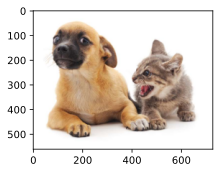

In [13]:
d2l.set_figsize()
print('input image shape:', img.permute(1, 2, 0).shape)
d2l.plt.imshow(img.permute(1, 2, 0));

output image shape: torch.Size([1122, 1456, 3])


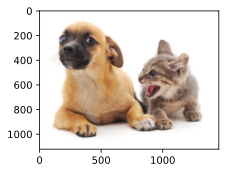

In [14]:
print('output image shape:', out_img.shape)
d2l.plt.imshow(out_img);

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


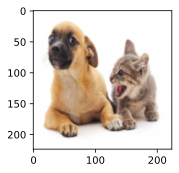

In [15]:
oout_img = torchvision.transforms.Resize((224,224))(out_img.permute(2, 0, 1))
d2l.plt.imshow(oout_img.permute(1, 2, 0))

In [16]:
3//2

1

In [20]:
og = (torch.arange(3).reshape(-1, 1), torch.arange(3).reshape(1, -1))
og

(tensor([[0],
         [1],
         [2]]),
 tensor([[0, 1, 2]]))

In [21]:
W = bilinear_kernel(num_classes, num_classes, 64)
net.transpose_conv.weight.data.copy_(W);

In [22]:
net.transpose_conv.weight.data = W

In [23]:
batch_size, crop_size = 32, (320, 480)
train_iter, test_iter = d2l.load_data_voc(batch_size, crop_size)

read 1114 examples
read 1078 examples


OutOfMemoryError: CUDA out of memory. Tried to allocate 394.00 MiB. GPU 0 has a total capacity of 8.00 GiB of which 3.94 GiB is free. Of the allocated memory 2.91 GiB is allocated by PyTorch, and 70.35 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

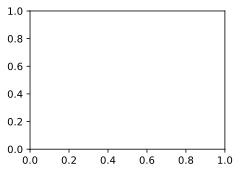

In [21]:
def loss(inputs, targets):
    return F.cross_entropy(inputs, targets, reduction='none').mean(1).mean(1) 
    # 第0维度是batch,这里是将输入输出的通道都进行取平均并且降维。mean(1)先是输入通道降维后
    # 又mean(1)则是针对输出通道

num_epochs, lr, wd, devices = 5, 0.001, 1e-3, d2l.try_all_gpus()
trainer = torch.optim.SGD(net.parameters(), lr=lr, weight_decay=wd)
d2l.train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices)

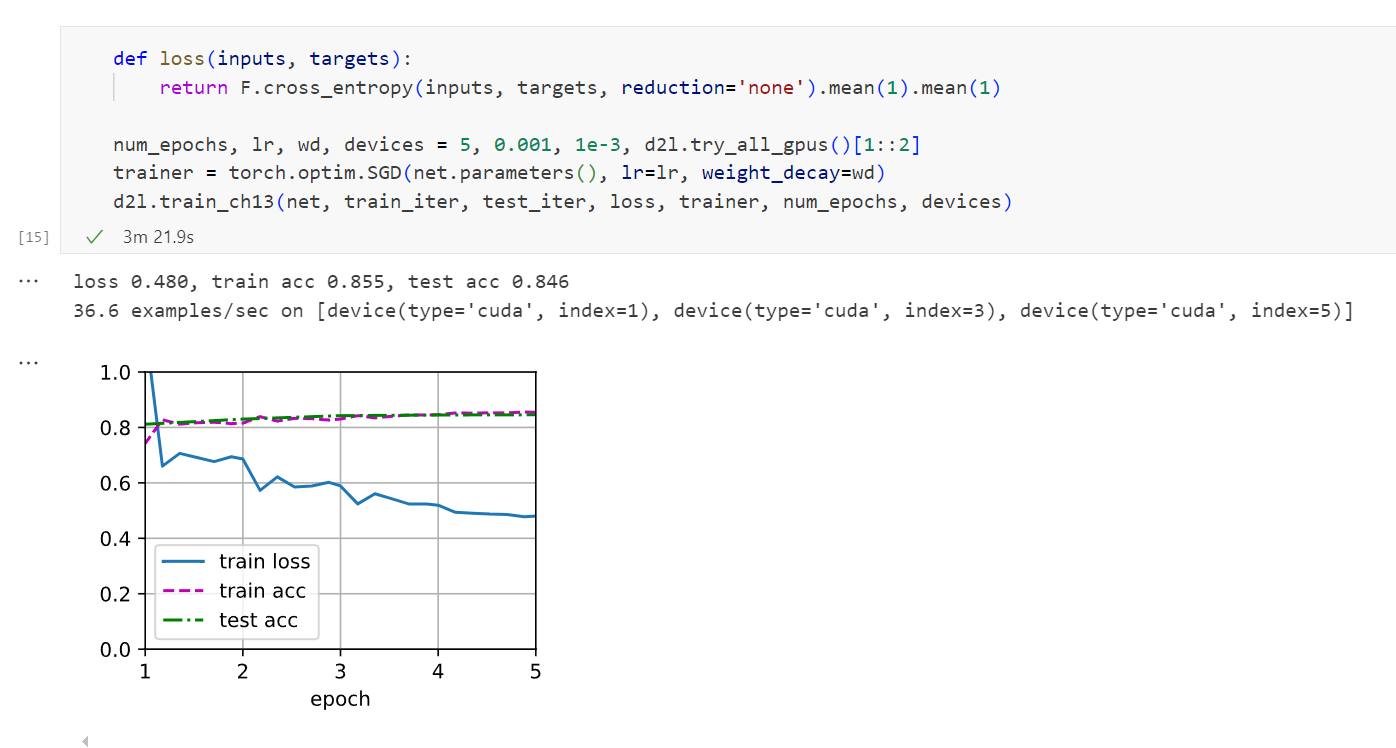

In [24]:
def predict(img):
    X = test_iter.dataset.normalize_image(img).unsqueeze(0)  # dataset就是自定义的dataset类 能用对应的方法
    # 这是将所有像素都除以255并转为float
    pred = net(X.to(devices[0])).argmax(dim=1) # 是一张张图传入的,batch为1,所以前面unsqueeze了一下
    # 21channel每个是一个类 所以这里dim=1
    return pred.reshape(pred.shape[1], pred.shape[2]) # 相当于squeeze

In [25]:
def label2image(pred):
    colormap = torch.tensor(d2l.VOC_COLORMAP, device=devices[0])
    X = pred.long()
    return colormap[X, :]

In [26]:
voc_dir = d2l.download_extract('voc2012', 'VOCdevkit/VOC2012')
test_images, test_labels = d2l.read_voc_images(voc_dir, False)
n, imgs = 4, []
for i in range(n):
    crop_rect = (0, 0, 320, 480)
    X = torchvision.transforms.functional.crop(test_images[i], *crop_rect)
    pred = label2image(predict(X))
    imgs += [X.permute(1,2,0), pred.cpu(),
             torchvision.transforms.functional.crop(
                 test_labels[i], *crop_rect).permute(1,2,0)]
d2l.show_images(imgs[::3] + imgs[1::3] + imgs[2::3], 3, n, scale=2);

NameError: name 'devices' is not defined

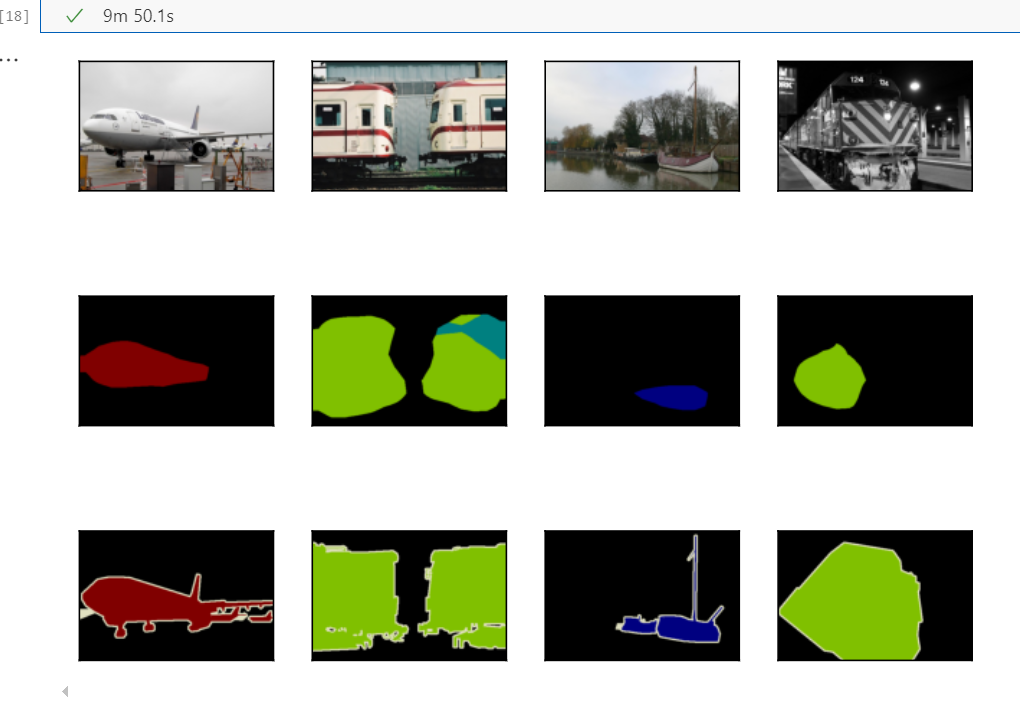

In [28]:
torch.arange(20).reshape(2,5,2).reshape(5,2)

RuntimeError: shape '[5, 2]' is invalid for input of size 20

In [30]:
[1,2,3][0::2]

[1, 3]

In [31]:
test_iter.batch_size

32

In [34]:
torch.arange(20).reshape(1,2,5,1,2,1).squeeze().shape

torch.Size([2, 5, 2])

## 样式迁移
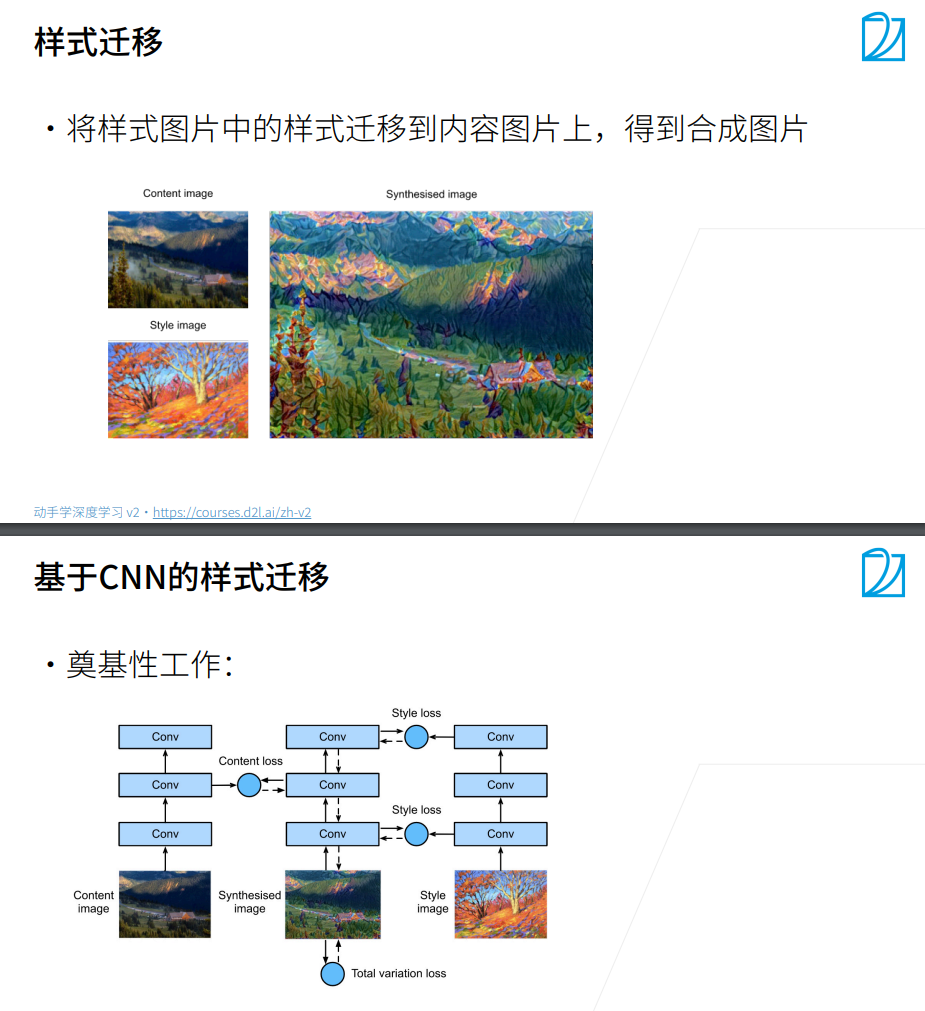

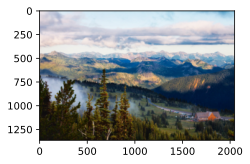

In [35]:
%matplotlib inline
import torch
import torchvision
from torch import nn
from d2l import torch as d2l

d2l.set_figsize()
content_img = d2l.Image.open('../data/img/rainier.jpg')
d2l.plt.imshow(content_img);

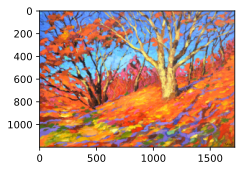

In [37]:
style_img = d2l.Image.open('../data/img/autumn-oak.jpg')
d2l.plt.imshow(style_img);

In [38]:
rgb_mean = torch.tensor([0.485, 0.456, 0.406])
rgb_std = torch.tensor([0.229, 0.224, 0.225])

def preprocess(img, image_shape):
    transforms = torchvision.transforms.Compose([
        torchvision.transforms.Resize(image_shape),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(mean=rgb_mean, std=rgb_std)])
    return transforms(img).unsqueeze(0)

def postprocess(img):
    img = img[0].to(rgb_std.device)
    img = torch.clamp(img.permute(1, 2, 0) * rgb_std + rgb_mean, 0, 1) # 原来到原来没有做过normalize之前的
    return torchvision.transforms.ToPILImage()(img.permute(2, 0, 1))

In [39]:
pretrained_net = torchvision.models.vgg19(pretrained=True)

D:\Pycharm\venv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
D:\Pycharm\venv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to C:\Users\Lollipop/.cache\torch\hub\checkpoints\vgg19-dcbb9e9d.pth
100%|███████████████████████████████████████████████████████████████████████████████| 548M/548M [04:36<00:00, 2.08MB/s]


In [40]:
style_layers, content_layers = [0, 5, 10, 19, 28], [25]  # 前面都是一些纹理，越后面才能得到一个较大的内容
# 所以内容层选在25层

In [44]:
pretrained_net

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [46]:
pretrained_net.features # 可以索引

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

In [47]:
net = nn.Sequential(*[pretrained_net.features[i] for i in
                      range(max(content_layers + style_layers) + 1)])  # 最大的层号后面的都不需要了

In [48]:
def extract_features(X, content_layers, style_layers):
    contents = []
    styles = []
    for i in range(len(net)):
        X = net[i](X)
        if i in style_layers:
            styles.append(X)
        if i in content_layers:
            contents.append(X)
    return contents, styles

In [49]:
def get_contents(image_shape, device):
    content_X = preprocess(content_img, image_shape).to(device)
    contents_Y, _ = extract_features(content_X, content_layers, style_layers)
    return content_X, contents_Y

def get_styles(image_shape, device):
    style_X = preprocess(style_img, image_shape).to(device)
    _, styles_Y = extract_features(style_X, content_layers, style_layers)
    return style_X, styles_Y

In [50]:
def content_loss(Y_hat, Y):
    # 我们从动态计算梯度的树中分离目标：
    # 这是一个规定的值，而不是一个变量。
    return torch.square(Y_hat - Y.detach()).mean()

In [51]:
def gram(X):
    num_channels, n = X.shape[1], X.numel() // X.shape[1]
    X = X.reshape((num_channels, n))
    return torch.matmul(X, X.T) / (num_channels * n)   
# 样式被认为是协方差（对角线是方差） 协方差矩阵是3*3的说明是各个通道之间的关系（这里没有减去均值是因为均值默认为0？）
# 方差和协方差相似被认为是样式相似

In [52]:
def style_loss(Y_hat, gram_Y):
    return torch.square(gram(Y_hat) - gram_Y.detach()).mean()

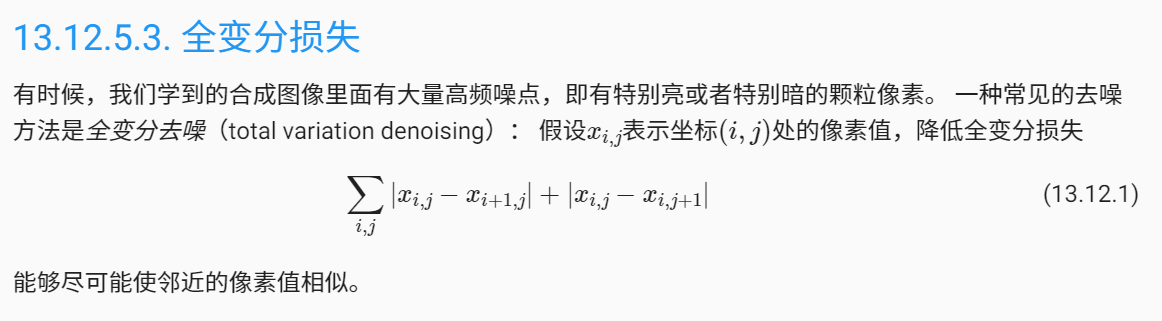

In [53]:
def tv_loss(Y_hat):
    return 0.5 * (torch.abs(Y_hat[:, :, 1:, :] - Y_hat[:, :, :-1, :]).mean() +
                  torch.abs(Y_hat[:, :, :, 1:] - Y_hat[:, :, :, :-1]).mean())

In [54]:
content_weight, style_weight, tv_weight = 1, 1e3, 10

def compute_loss(X, contents_Y_hat, styles_Y_hat, contents_Y, styles_Y_gram):
    # 分别计算内容损失、风格损失和全变分损失
    contents_l = [content_loss(Y_hat, Y) * content_weight for Y_hat, Y in zip(
        contents_Y_hat, contents_Y)]
    styles_l = [style_loss(Y_hat, Y) * style_weight for Y_hat, Y in zip(
        styles_Y_hat, styles_Y_gram)]
    tv_l = tv_loss(X) * tv_weight
    # 对所有损失求和
    l = sum(10 * styles_l + contents_l + [tv_l])
    return contents_l, styles_l, tv_l, l

In [55]:
class SynthesizedImage(nn.Module):  # 继承nn.Module  后面才能当做参数传到trainer里面
    def __init__(self, img_shape, **kwargs):
        super(SynthesizedImage, self).__init__(**kwargs)
        self.weight = nn.Parameter(torch.rand(*img_shape)) # 就是直接训练出一张图片

    def forward(self):
        return self.weight

In [85]:
SynthesizedImage((3,3)).parameters

<bound method Module.parameters of SynthesizedImage()>

In [63]:
for i in style_img:
    print(i)

TypeError: 'JpegImageFile' object is not iterable

In [64]:
def get_inits(X, device, lr, styles_Y):
    global gen_img
    gen_img = SynthesizedImage(X.shape).to(device)
    gen_img.weight.data.copy_(X.data)
    # 从原图的作为初始值开始训练
    trainer = torch.optim.Adam(gen_img.parameters(), lr=lr) # 这里继承了nn.module 所以有parameters这个属性
    styles_Y_gram = [gram(Y) for Y in styles_Y]
    return gen_img(), styles_Y_gram, trainer  # __call__就是forward

In [80]:
def myget_inits(X, device, lr, styles_Y):
    global gen_img
    gen_img = nn.Parameter(X.data).to(device)
    trainer = torch.optim.Adam(gen_img, lr=lr)
    styles_Y_gram = [gram(Y) for Y in styles_Y]
    return gen_img(), styles_Y_gram, trainer

In [89]:
gen_img()

TypeError: 'Parameter' object is not callable

In [58]:
def train(X, contents_Y, styles_Y, device, lr, num_epochs, lr_decay_epoch):
    # X是原图, contens_Y是内容图片所有内容层的列表, styles_Y是样式图片所有样式层的列表
    X, styles_Y_gram, trainer = get_inits(X, device, lr, styles_Y)
    scheduler = torch.optim.lr_scheduler.StepLR(trainer, lr_decay_epoch, 0.8)
    animator = d2l.Animator(xlabel='epoch', ylabel='loss',
                            xlim=[10, num_epochs],
                            legend=['content', 'style', 'TV'],
                            ncols=2, figsize=(7, 2.5))
    for epoch in range(num_epochs):
        trainer.zero_grad()
        contents_Y_hat, styles_Y_hat = extract_features(
            X, content_layers, style_layers) # 对内容图片得到他的内容层列表和 样式层列表
        contents_l, styles_l, tv_l, l = compute_loss(
            X, contents_Y_hat, styles_Y_hat, contents_Y, styles_Y_gram)
        l.backward()
        trainer.step()
        scheduler.step()
        if (epoch + 1) % 10 == 0:
            animator.axes[1].imshow(postprocess(X))
            animator.add(epoch + 1, [float(sum(contents_l)),
                                     float(sum(styles_l)), float(tv_l)])
    return X

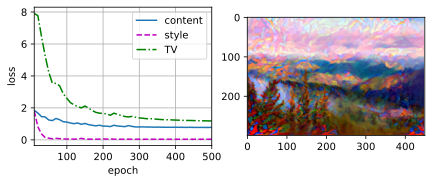

In [66]:
device, image_shape = d2l.try_gpu(), (300, 450)
net = net.to(device)
content_X, contents_Y = get_contents(image_shape, device)
_, styles_Y = get_styles(image_shape, device)
output = train(content_X, contents_Y, styles_Y, device, 0.3, 500, 50)

In [68]:
gen_img.weight

Parameter containing:
tensor([[[[ 1.9376,  1.9398,  1.9375,  ...,  0.4968,  0.4969,  0.5023],
          [ 1.9367,  1.9319,  1.9367,  ...,  0.4952,  0.4981,  0.4957],
          [ 1.9354,  1.9330,  1.9330,  ...,  0.4977,  0.4956,  0.4969],
          ...,
          [-1.3829, -1.3761, -0.7215,  ...,  0.7851,  0.7808,  0.7477],
          [-1.3879, -1.3800, -1.3718,  ...,  0.7532,  0.7589,  0.7487],
          [-1.3875, -1.3815, -1.3750,  ...,  0.7481,  0.7458,  0.7465]],

         [[ 1.6021,  1.6009,  1.5997,  ...,  1.3188,  1.3164,  1.3208],
          [ 1.6016,  1.6015,  1.6005,  ...,  1.3187,  1.3231,  1.3193],
          [ 1.6949,  1.6954,  1.9280,  ...,  1.3209,  1.3266,  1.3293],
          ...,
          [-0.9499, -0.7599, -0.7357,  ..., -1.4669, -1.4646, -1.4659],
          [-1.2694, -1.2635, -1.2715,  ..., -1.4587, -1.4618, -1.4658],
          [-1.2807, -1.2789, -1.2661,  ..., -1.4590, -1.4654, -1.4657]],

         [[ 2.0007,  2.0016,  2.0071,  ...,  2.3530,  2.3581,  2.3688],
        

In [71]:
content_X

tensor([[[[ 1.9235,  1.9407,  1.9578,  ...,  0.0569,  0.0569,  0.0912],
          [ 1.9235,  1.9407,  1.9578,  ...,  0.1426,  0.1426,  0.1768],
          [ 1.9235,  1.9235,  1.9407,  ...,  0.2282,  0.2111,  0.2111],
          ...,
          [-1.8782, -1.8439, -1.8268,  ..., -1.6384, -0.8164, -0.8507],
          [-1.8782, -1.8439, -1.8268,  ..., -1.6213, -1.2617, -1.1418],
          [-1.8782, -1.8782, -1.8610,  ..., -1.8439, -1.7069, -1.5528]],

         [[ 1.9909,  1.9909,  1.9734,  ...,  1.2206,  1.2206,  1.2556],
          [ 1.9909,  1.9909,  1.9734,  ...,  1.2731,  1.2731,  1.3081],
          [ 1.9909,  1.9734,  1.9559,  ...,  1.3431,  1.3256,  1.3256],
          ...,
          [-1.8256, -1.7906, -1.7731,  ..., -1.6506, -1.0203, -1.1253],
          [-1.8256, -1.7906, -1.7731,  ..., -1.5630, -1.3704, -1.2654],
          [-1.8256, -1.8256, -1.8081,  ..., -1.7731, -1.6856, -1.5630]],

         [[ 2.2740,  2.2740,  2.2740,  ...,  1.9603,  1.9603,  1.9951],
          [ 2.2740,  2.2740,  

In [86]:
nn.Parameter(content_X.data),nn.Parameter(content_X.data).shape

(Parameter containing:
 tensor([[[[ 1.9235,  1.9407,  1.9578,  ...,  0.0569,  0.0569,  0.0912],
           [ 1.9235,  1.9407,  1.9578,  ...,  0.1426,  0.1426,  0.1768],
           [ 1.9235,  1.9235,  1.9407,  ...,  0.2282,  0.2111,  0.2111],
           ...,
           [-1.8782, -1.8439, -1.8268,  ..., -1.6384, -0.8164, -0.8507],
           [-1.8782, -1.8439, -1.8268,  ..., -1.6213, -1.2617, -1.1418],
           [-1.8782, -1.8782, -1.8610,  ..., -1.8439, -1.7069, -1.5528]],
 
          [[ 1.9909,  1.9909,  1.9734,  ...,  1.2206,  1.2206,  1.2556],
           [ 1.9909,  1.9909,  1.9734,  ...,  1.2731,  1.2731,  1.3081],
           [ 1.9909,  1.9734,  1.9559,  ...,  1.3431,  1.3256,  1.3256],
           ...,
           [-1.8256, -1.7906, -1.7731,  ..., -1.6506, -1.0203, -1.1253],
           [-1.8256, -1.7906, -1.7731,  ..., -1.5630, -1.3704, -1.2654],
           [-1.8256, -1.8256, -1.8081,  ..., -1.7731, -1.6856, -1.5630]],
 
          [[ 2.2740,  2.2740,  2.2740,  ...,  1.9603,  1.9603, 

In [74]:
def mytrain(X, contents_Y, styles_Y, device, lr, num_epochs, lr_decay_epoch):
    X, styles_Y_gram, trainer = myget_inits(X, device, lr, styles_Y)
    scheduler = torch.optim.lr_scheduler.StepLR(trainer, lr_decay_epoch, 0.8)
    animator = d2l.Animator(xlabel='epoch', ylabel='loss',
                            xlim=[10, num_epochs],
                            legend=['content', 'style', 'TV'],
                            ncols=2, figsize=(7, 2.5))
    for epoch in range(num_epochs):
        trainer.zero_grad()
        contents_Y_hat, styles_Y_hat = extract_features(
            X, content_layers, style_layers)
        contents_l, styles_l, tv_l, l = compute_loss(
            X, contents_Y_hat, styles_Y_hat, contents_Y, styles_Y_gram)
        l.backward()
        trainer.step()
        scheduler.step()
        if (epoch + 1) % 10 == 0:
            animator.axes[1].imshow(postprocess(X))
            animator.add(epoch + 1, [float(sum(contents_l)),
                                     float(sum(styles_l)), float(tv_l)])
    return X

In [81]:
device, image_shape = d2l.try_gpu(), (300, 450)
net = net.to(device)
content_X, contents_Y = get_contents(image_shape, device)
_, styles_Y = get_styles(image_shape, device)
output = mytrain(content_X, contents_Y, styles_Y, device, 0.3, 500, 50)

TypeError: params argument given to the optimizer should be an iterable of Tensors or dicts, but got torch.cuda.FloatTensor

In [93]:
gen_imga = SynthesizedImage((3,3)).to(device)
gen_imga()

Parameter containing:
tensor([[0.2796, 0.6280, 0.8215],
        [0.3581, 0.4979, 0.7936],
        [0.1553, 0.8673, 0.9214]], device='cuda:0', requires_grad=True)

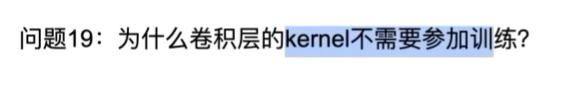
卷积层只是用来抽特征的，不用更新